---
##  Section 1: Imports & Setup

In [1]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0


from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.20.0
GPU        : []


---
##  Section 2: Configuration

In [2]:
BASE_PATH  = '/Users/anshikalohan/Downloads/modality_dataset'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
TEST_PATH  = os.path.join(BASE_PATH, 'test')

CLASSES     = ['brain', 'lung', 'skin']
NUM_CLASSES = len(CLASSES)
PALETTE     = {'brain': '#4C72B0', 'lung': '#55A868', 'skin': '#C44E52'}

IMG_SIZE    = 224
IMG_SHAPE   = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE  = 16    
EPOCHS      = 30    

MODEL_SAVE_PATH = 'modality_classifier.h5'

print(f"Batch size      : {BATCH_SIZE}")
print(f"Steps per epoch : {144 * 3 // BATCH_SIZE} (approx)")
print(f"Max epochs      : {EPOCHS} (EarlyStopping will stop early)")

Batch size      : 16
Steps per epoch : 27 (approx)
Max epochs      : 30 (EarlyStopping will stop early)


---
##  Section 3: Exploratory Data Analysis

In [3]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}

def count_images(split_path, classes):
    counts = {}
    for cls in classes:
        folder = os.path.join(split_path, cls)
        files  = [f for f in os.listdir(folder)
                  if os.path.splitext(f)[1].lower() in VALID_EXTS]
        counts[cls] = len(files)
    return counts

train_counts = count_images(TRAIN_PATH, CLASSES)
test_counts  = count_images(TEST_PATH,  CLASSES)

df = pd.DataFrame({'Class': CLASSES,
                   'Train': [train_counts[c] for c in CLASSES],
                   'Test' : [test_counts[c]  for c in CLASSES]})
df['Total'] = df['Train'] + df['Test']
print(df.to_string(index=False))
print(f"\nTotal train: {df['Train'].sum()} | Total test: {df['Test'].sum()}")

Class  Train  Test  Total
brain    144    30    174
 lung    144    30    174
 skin    144    30    174

Total train: 432 | Total test: 90


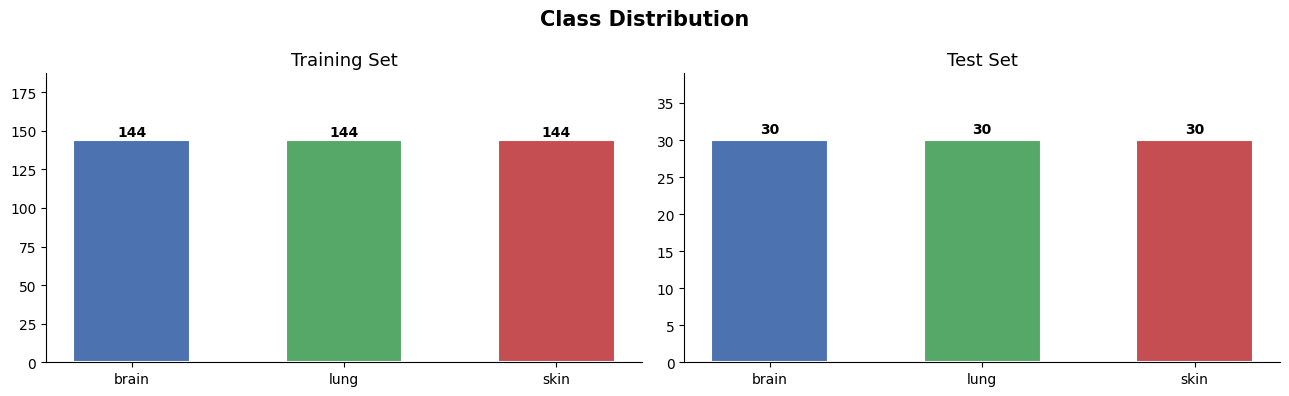

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Class Distribution', fontsize=15, fontweight='bold')

for ax, split, counts in zip(axes, ['Training Set', 'Test Set'],
                              [train_counts, test_counts]):
    vals   = [counts[c] for c in CLASSES]
    colors = [PALETTE[c] for c in CLASSES]
    bars   = ax.bar(CLASSES, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5, str(val),
                ha='center', va='bottom', fontweight='bold')
    ax.set_title(split, fontsize=13)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

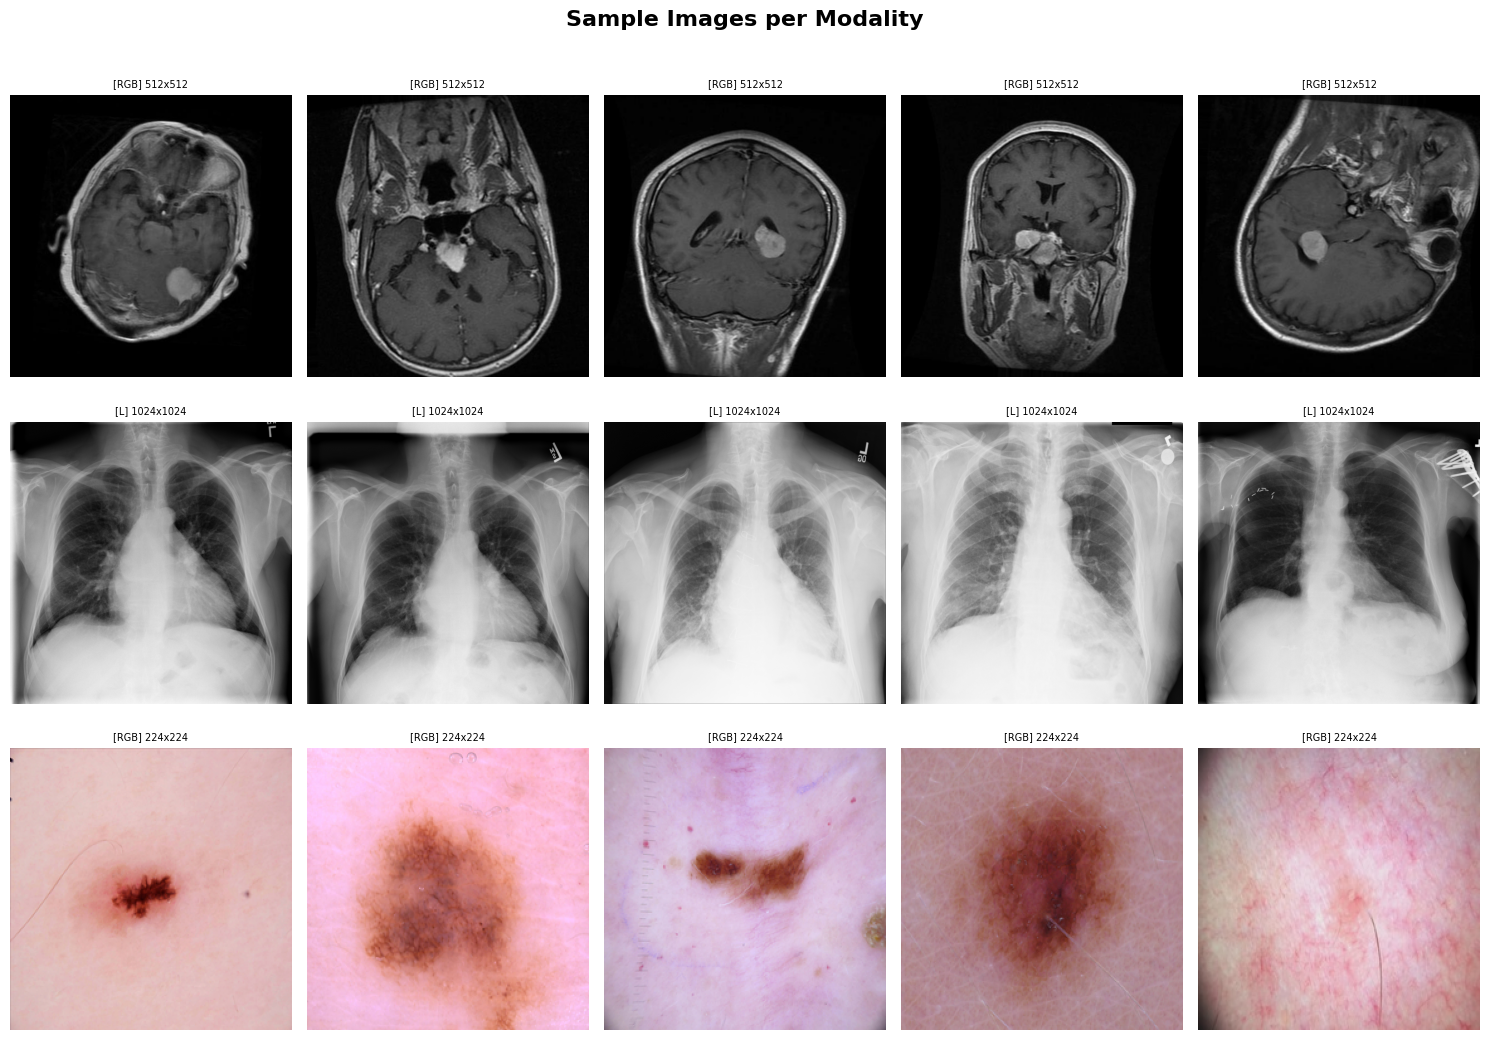

In [5]:
def get_sample_paths(split_path, cls, n=5):
    folder = os.path.join(split_path, cls)
    files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                     if os.path.splitext(f)[1].lower() in VALID_EXTS])
    return files[:n]

N = 5
fig, axes = plt.subplots(NUM_CLASSES, N, figsize=(3*N, 3.5*NUM_CLASSES))
fig.suptitle('Sample Images per Modality', fontsize=16, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASSES):
    for col, path in enumerate(get_sample_paths(TRAIN_PATH, cls, N)):
        ax  = axes[row][col]
        img = Image.open(path)
        ax.imshow(img, cmap='gray' if img.mode in ('L','LA') else None)
        ax.set_title(f'[{img.mode}] {img.size[0]}x{img.size[1]}', fontsize=7)
        ax.axis('off')
    axes[row][0].set_ylabel(cls.upper(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
def find_corrupted(split_path, classes):
    bad, total = [], 0
    for cls in classes:
        for f in os.listdir(os.path.join(split_path, cls)):
            if os.path.splitext(f)[1].lower() not in VALID_EXTS:
                continue
            total += 1
            path = os.path.join(split_path, cls, f)
            try:
                Image.open(path).verify()
            except Exception as e:
                bad.append((path, str(e)))
    return bad, total

for split, path in [('Train', TRAIN_PATH), ('Test', TEST_PATH)]:
    bad, total = find_corrupted(path, CLASSES)
    status = f"{len(bad)} corrupted" if bad else "all OK"
    print(f"{split}: {total} images scanned — {status}")

Train: 432 images scanned — all OK
Test: 90 images scanned — all OK


---
##  Section 4: Preprocessing & Data Generators

In [7]:

def preprocess_fn(img_array):
    """
    Applied by ImageDataGenerator before feeding each batch to the model.
    - img_array: float32 numpy array, pixel values 0–255, shape (H, W, 3)
    - Returns: float32 array in [-1, 1] — EfficientNetB0's expected range
    """
    
    if img_array.ndim == 2:
        img_array = np.stack([img_array] * 3, axis=-1)
    elif img_array.shape[-1] == 1:
        img_array = np.concatenate([img_array] * 3, axis=-1)

    
    return efficientnet_preprocess(img_array)


train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_fn,
    rotation_range         = 30,      
    zoom_range             = 0.20,    
    width_shift_range      = 0.15,    
    height_shift_range     = 0.15,    
    horizontal_flip        = True,
    vertical_flip          = False,   
    brightness_range       = [0.8, 1.2],   
    shear_range            = 10,           
    fill_mode              = 'nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_fn
)

print(" Preprocessing: EfficientNet preprocess_input (maps [0,255] → [-1,1])")
print(" Augmentation : rotation=30, zoom=20%, brightness, shear, flip")

 Preprocessing: EfficientNet preprocess_input (maps [0,255] → [-1,1])
 Augmentation : rotation=30, zoom=20%, brightness, shear, flip


---
##  Section 5: Load Data

In [8]:
train_generator = train_datagen.flow_from_directory(
    directory   = TRAIN_PATH,
    target_size = (IMG_SIZE, IMG_SIZE),
    color_mode  = 'rgb',           
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = SEED
)

test_generator = test_datagen.flow_from_directory(
    directory   = TEST_PATH,
    target_size = (IMG_SIZE, IMG_SIZE),
    color_mode  = 'rgb',
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False,           
    seed        = SEED
)

CLASS_INDICES = train_generator.class_indices  # e.g. {'brain':0, 'lung':1, 'skin':2}
IDX_TO_CLASS  = {v: k for k, v in CLASS_INDICES.items()}

print(f"Class mapping    : {CLASS_INDICES}")
print(f"Training samples : {train_generator.samples}")
print(f"Test samples     : {test_generator.samples}")
print(f"Steps/epoch      : {len(train_generator)} (= {train_generator.samples}/{BATCH_SIZE})")

Found 432 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Class mapping    : {'brain': 0, 'lung': 1, 'skin': 2}
Training samples : 432
Test samples     : 90
Steps/epoch      : 27 (= 432/16)


In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_generator.classes),
    y            = train_generator.classes
)
CLASS_WEIGHTS = dict(enumerate(class_weights_array))
print(f"Class weights: {CLASS_WEIGHTS}")
# For a balanced dataset these will all be ~1.0, but it's a good habit

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


---
##  Section 6: Build Model


In [10]:
def build_model(num_unfrozen_layers=30):
    """
    Build EfficientNetB0 classifier with partial unfreezing.

    num_unfrozen_layers: how many layers from the TOP of EfficientNetB0
    to leave trainable. Layers below are frozen (pretrained ImageNet weights
    for low-level features like edges and textures — universally useful).
    """
    
    base = EfficientNetB0(
        weights     = 'imagenet',
        include_top = False,
        input_shape = IMG_SHAPE
    )

    
    base.trainable = True
    for layer in base.layers[:-num_unfrozen_layers]:
        layer.trainable = False

    
    trainable   = sum(1 for l in base.layers if l.trainable)
    total_base  = len(base.layers)
    print(f"Base model: {total_base} layers total, "
          f"{trainable} trainable (top {num_unfrozen_layers}), "
          f"{total_base - trainable} frozen")

   
    inputs = keras.Input(shape=IMG_SHAPE)

    
    x = base(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name='MedModality_v2')
    return model


model = build_model(num_unfrozen_layers=30)


model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

model.summary()

Base model: 238 layers total, 30 trainable (top 30), 208 frozen


Model: "MedModality_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,875,174 (18.60 MB)

 Trainable params: 2,319,203 (8.85 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

---
##  Section 7: Train the Model

In [11]:
early_stop = EarlyStopping(
    monitor              = 'val_accuracy',   
    patience             = 8,                
    verbose              = 1,
    restore_best_weights = True
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.3,        
    patience = 4,
    verbose  = 1,
    min_lr   = 1e-7
)

checkpoint = ModelCheckpoint(
    filepath          = 'best_checkpoint.h5',
    monitor           = 'val_accuracy',
    save_best_only    = True,
    verbose           = 1
)

callbacks = [early_stop, reduce_lr, checkpoint]
print(" Callbacks ready")

 Callbacks ready


In [12]:
print(" Training...")

history = model.fit(
    train_generator,
    epochs           = EPOCHS,
    steps_per_epoch  = len(train_generator),
    validation_data  = test_generator,
    validation_steps = len(test_generator),
    class_weight     = CLASS_WEIGHTS,    
    callbacks        = callbacks,
    verbose          = 1
)

best_val_acc = max(history.history['val_accuracy'])
print(f"\n Training complete — Best val_accuracy: {best_val_acc*100:.2f}%")

 Training...
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.3800 - loss: 1.4970
Epoch 1: val_accuracy improved from None to 0.98889, saving model to best_checkpoint.h5



Epoch 1: finished saving model to best_checkpoint.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 283ms/step - accuracy: 0.4977 - loss: 1.1602 - val_accuracy: 0.9889 - val_loss: 0.7562 - learning_rate: 1.0000e-04
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7107 - loss: 0.6572
Epoch 2: val_accuracy improved from 0.98889 to 1.00000, saving model to best_checkpoint.h5



Epoch 2: finished saving model to best_checkpoint.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 232ms/step - accuracy: 0.7500 - loss: 0.5703 - val_accuracy: 1.0000 - val_loss: 0.4440 - learning_rate: 1.0000e-04
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.8488 - loss: 0.3650
Epoch 3: val_accuracy did not improve from 1.00000
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.8773 - loss: 0.3108 - val_accuracy: 1.0000 - val_loss: 0.2365 - learning_rate: 1.0000e-04
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9323 - loss: 0.1817
Epoch 4: val_accuracy did not improve from 1.00000
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - accuracy: 0.9259 - loss: 0.1879 - val_accuracy: 1.0000 - val_loss: 0.1247 - learning_rate: 1.0000e-04
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9625 - loss: 0.1252
Epoch 5: val_accuracy did not improve from 1.00000
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 236ms/step - accuracy: 0.9653 - loss: 0.1178 - val_accuracy: 1.0000 - 

---
##  Section 8: Training Curves

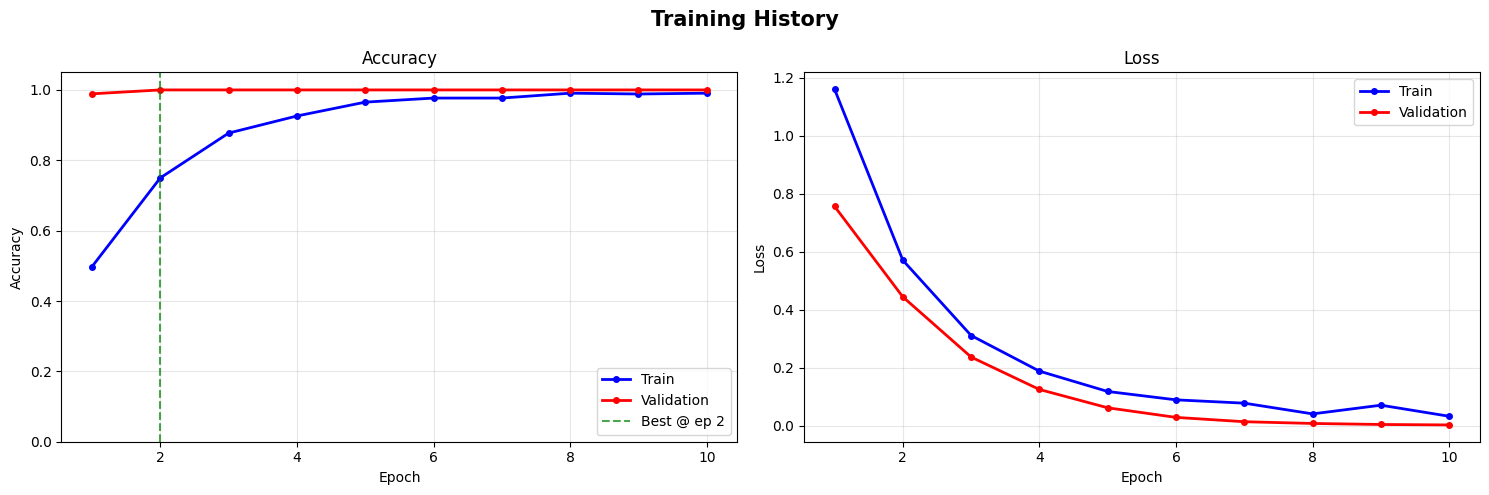

In [13]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
ep_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Training History', fontsize=15, fontweight='bold')

ax1.plot(ep_range, acc,     'b-o', label='Train',      lw=2, ms=4)
ax1.plot(ep_range, val_acc, 'r-o', label='Validation', lw=2, ms=4)
best_ep = val_acc.index(max(val_acc)) + 1
ax1.axvline(best_ep, color='green', ls='--', alpha=0.7, label=f'Best @ ep {best_ep}')
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.set_ylim([0, 1.05]); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_range, loss,     'b-o', label='Train',      lw=2, ms=4)
ax2.plot(ep_range, val_loss, 'r-o', label='Validation', lw=2, ms=4)
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
##  Section 9: Evaluation

In [14]:
test_generator.reset()
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 1.0000 - loss: 0.4440

Test Accuracy : 100.00%
Test Loss     : 0.4440


In [15]:
test_generator.reset()
y_prob = model.predict(test_generator, steps=len(test_generator), verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

y_pred_names = [IDX_TO_CLASS[i] for i in y_pred]
y_true_names = [IDX_TO_CLASS[i] for i in y_true]

print("\n Classification Report")
print("=" * 60)
print(classification_report(y_true_names, y_pred_names,
                             target_names=CLASSES, digits=4))

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 327ms/step

 Classification Report
              precision    recall  f1-score   support

       brain     1.0000    1.0000    1.0000        30
        lung     1.0000    1.0000    1.0000        30
        skin     1.0000    1.0000    1.0000        30

    accuracy                         1.0000        90
   macro avg     1.0000    1.0000    1.0000        90
weighted avg     1.0000    1.0000    1.0000        90



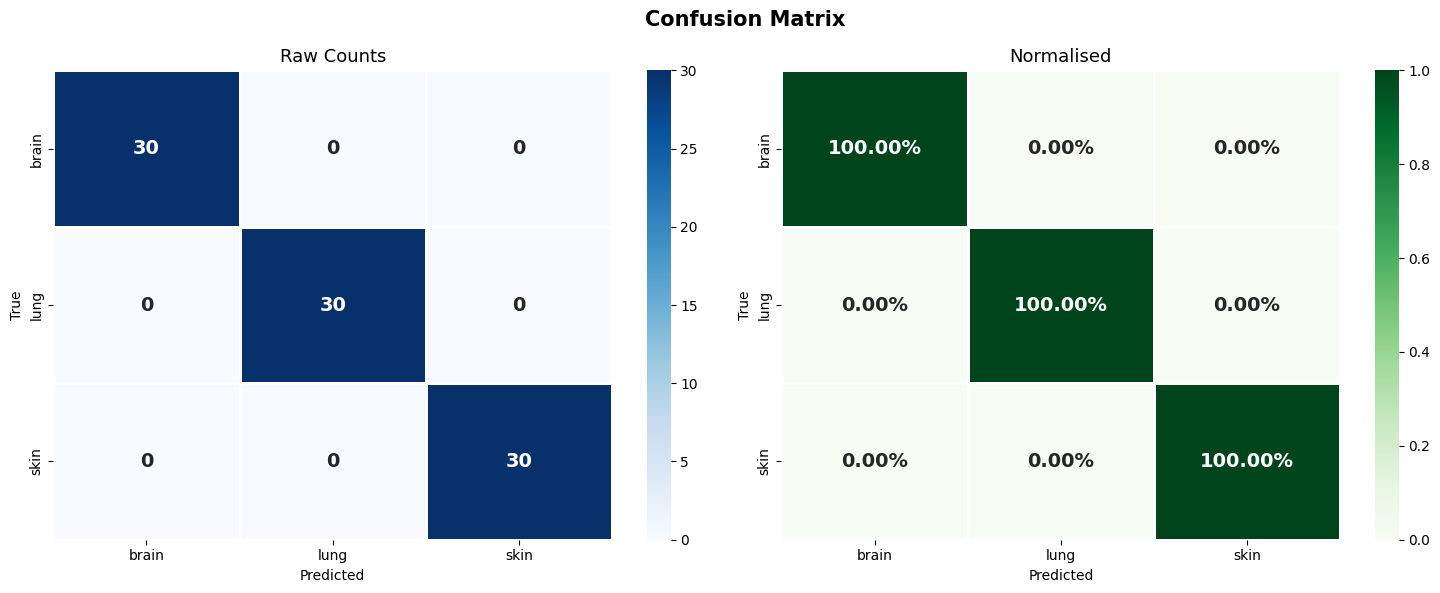


Per-Class Accuracy:
  brain   : 30/30  (100.0%)
  lung    : 30/30  (100.0%)
  skin    : 30/30  (100.0%)


In [16]:
cm      = confusion_matrix(y_true_names, y_pred_names, labels=CLASSES)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confusion Matrix', fontsize=15, fontweight='bold')

for ax, data, fmt, title, cmap in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2%'],
        ['Raw Counts', 'Normalised'],
        ['Blues', 'Greens']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.8, ax=ax, annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.show()

print("\nPer-Class Accuracy:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:8s}: {cm[i,i]}/{cm[i].sum()}  ({cm[i,i]/cm[i].sum()*100:.1f}%)")

---
##  Section 10: Save Model

In [17]:
model.save(MODEL_SAVE_PATH)
size_mb = os.path.getsize(MODEL_SAVE_PATH) / (1024**2)
print(f" Saved: {MODEL_SAVE_PATH}  ({size_mb:.1f} MB)")

 Saved: modality_classifier.h5  (36.8 MB)


In [18]:
loaded = keras.models.load_model(MODEL_SAVE_PATH)
loaded.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
test_generator.reset()
_, reload_acc = loaded.evaluate(test_generator, verbose=0)
print(f" Reload check — accuracy: {reload_acc*100:.2f}% (should match above)")

 Reload check — accuracy: 100.00% (should match above)
